# Creating a Flood Frequncy Map

## Overview

[Google Groundsource](https://zenodo.org/records/18647054) is a dataset of high-resolution flood observation derived from news articles. It contains data of flood events from 2000-2025 with precise dates extracted from the text and the corresponding geographic polygons derived from geocoding locations from Google Maps boundaries. The full dataset contains 2.6 million records and is available as a Parquet file. This notebook demonstrates how to use GeoPandas to efficiently load, filter, and analyze this large Parquet dataset to aggregate this records over a regular grid and create a flood frequency map for your chosen country.

**Input Layers**:
* `groundsource_2026.parquet`: Google Groundsource flood observations dataset (Parquet format)
* `ne_10m_admin_0_countries_ind.zip`: Natural Earth Admin0 country boundaries shapefile

**Output**:
* `flood_frequency_grid.gpkg`: A GeoPackage with a layer of 10km x 10km grid cells with flood event counts.

**Data Credit**

* Google Groundsource dataset: [https://zenodo.org/records/18647054](https://zenodo.org/records/18647054)
* Natural Earth: [https://www.naturalearthdata.com/](https://www.naturalearthdata.com/)

**Running the Notebook**:  
The preferred way to run this notebook is on Google Colab.  <a href='https://colab.research.google.com/github/spatialthoughts/geopython-tutorials/blob/main/notebooks/geopandas_flood_frequency.ipynb' target='_parent'><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup and Data Download

The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [5]:
import os
import geopandas as gpd
import pandas as pd
import shapely.wkb
from shapely import STRtree
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

In [ ]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

In [6]:
def download(url):
    filename = os.path.join(data_folder, os.path.basename(url).split('?')[0])
    if not os.path.exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    return filename

shapefile = 'ne_10m_admin_0_countries_ind.zip'
shapefile_url = f'https://naciscdn.org/naturalearth/10m/cultural/{shapefile}'

parquet_file = 'groundsource_2026.parquet'
parquet_url = f'https://zenodo.org/records/18647054/files/{parquet_file}?download=1'

download(shapefile_url)
download(parquet_url)

Downloaded data/ne_10m_admin_0_countries_ind.zip
Downloaded data/groundsource_2026.parquet


'data/groundsource_2026.parquet'

## Creating a Grid

Load the Natural Earth Admin0 boundaries and extract the polygon. Here we select India using the 3-digit ISO code.

In [7]:
shapefile_path = os.path.join(data_folder, shapefile)
gdf = gpd.read_file(shapefile_path, encoding='utf-8')
country = gdf[gdf['SOV_A3'] == 'IND']
country.iloc[:, :5]

,ADM0_A3_IN,featurecla,scalerank,LABELRANK,SOVEREIGNT
8,IND,Admin-0 country,0,2,India


Extract the bounding box.

Create a regular grid over the bounding box of the country, then use a spatial join to keep only cells that intersect the country boundary.

In [8]:
grid_size = 10000  # 10 km in metres
grid_crs = 'EPSG:7755' # India LCC

In [9]:
from shapely.geometry import box

cell_size = 10000  #  size in metres

country_proj = country.to_crs(grid_crs)
minx, miny, maxx, maxy = country_proj.total_bounds

xs = np.arange(minx, maxx, cell_size)
ys = np.arange(miny, maxy, cell_size)

polygons = [
    box(x, y, x + cell_size, y + cell_size)
    for x in xs
    for y in ys
]

grid = gpd.GeoDataFrame({'geometry': polygons}, crs=grid_crs)

# Keep only cells that intersect the country — faster than clip as it avoids
# computing exact geometric intersections along the boundary
grid_country = gpd.sjoin(grid, country_proj[['geometry']],
                         how='inner', predicate='intersects')
grid_country = grid_country.drop(columns=['index_right']).reset_index(drop=True)
print(f'Cells intersecting the country: {len(grid_country):,}')

Cells intersecting the country: 32,970


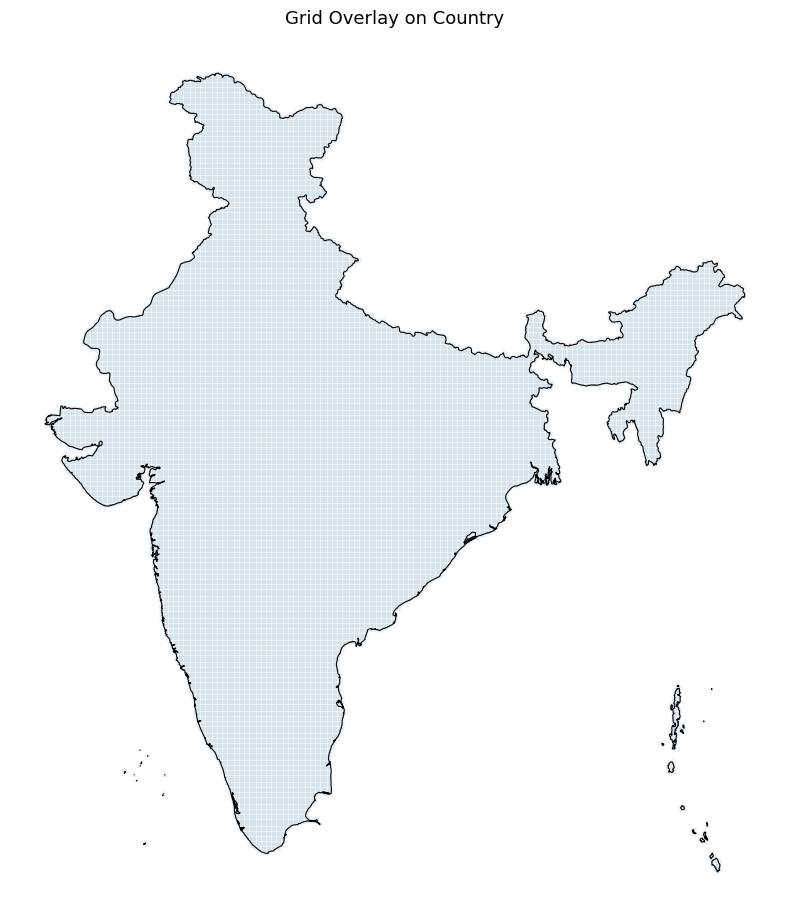

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 10))
grid_country.plot(ax=ax, facecolor='none', edgecolor='steelblue', linewidth=0.1, alpha=0.8)
country_proj.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)
ax.set_title('Grid Overlay on Country', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

## Pre-Processing Flood Data

Read the raw parquet file of groundsource observations.

In [12]:
parquet_file_path = os.path.join(data_folder, parquet_file)

df = pd.read_parquet(parquet_file_path, engine='pyarrow')
print('Total records in the dataset:', len(df))
df.head()

Total records in the dataset: 2646302


,uuid,area_km2,geometry,start_date,end_date
0,5acc1866dd6644dfa572f02ae3d54aa4,91.678015,"b""\x01\x06\x00\x00\x00\x02\x00\x00\x00\x01\x03...",2000-01-01,2000-01-01
1,f80fccbefb1346a9b568907086e65226,609.968365,b'\x01\x06\x00\x00\x00\x02\x00\x00\x00\x01\x03...,2000-01-01,2000-01-01
2,d5c49c9e2c2045bfbfd6e3b3865efc3f,0.099688,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,2000-01-24,2000-01-24
3,ce7f01a29de040b39e138f198fc39d86,0.548906,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,2000-01-30,2000-01-30
4,eb047dfea9ed406485010853226e0170,0.236562,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,2000-01-30,2000-01-30


The parquet file has geometry stored as WKB blobs. We convert it a GeoSeries and create a GeoDataFrame.


In [13]:
df['geometry'] = gpd.GeoSeries.from_wkb(df['geometry'])
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")
gdf.head()

,uuid,area_km2,geometry,start_date,end_date
0,5acc1866dd6644dfa572f02ae3d54aa4,91.678015,"MULTIPOLYGON (((8.64252 53.60898, 8.65179 53.6...",2000-01-01,2000-01-01
1,f80fccbefb1346a9b568907086e65226,609.968365,"MULTIPOLYGON (((-0.01457 51.65825, -0.00151 51...",2000-01-01,2000-01-01
2,d5c49c9e2c2045bfbfd6e3b3865efc3f,0.099688,"POLYGON ((-58.43034 -34.61363, -58.42461 -34.6...",2000-01-24,2000-01-24
3,ce7f01a29de040b39e138f198fc39d86,0.548906,"POLYGON ((23.44227 47.63646, 23.43369 47.6408,...",2000-01-30,2000-01-30
4,eb047dfea9ed406485010853226e0170,0.236562,"POLYGON ((-57.54008 -38.00748, -57.5575 -38.02...",2000-01-30,2000-01-30


We filter the data to the bounds of the chosen country. We use the [`cx`](https://geopandas.org/en/latest/docs/reference/api/geopandas.GeoDataFrame.cx.html) indexer to select the matching polygons within the bounding box. This is orders of magnitude faster than using `.clip()`.

In [14]:
geometry = country.geometry.union_all()
xmin, ymin, xmax, ymax = geometry.bounds
gdf_filtered= gdf.cx[xmin:xmax, ymin:ymax]
print('Total records within the country bounding box:', len(gdf_filtered))

Total records within the country bounding box: 445244


## Duplicate Flood Event Detection

One of the problems with the dataset is the presence of many duplicate records for the same flood event. While Google did perform some spatio-temporal aggregation, the dataset still has overlapping records from thesame flood event that have different geographic extent (captured from different articles) and/or slightly varying dates. Our goal is to count the total unique flood events aggregated for each grid. Such duplicates would show up as spatially intersecting polygons with `start_date` values within a few days of each other. We use a vectorized `STRtree` bulk query to find all such candidate pairs efficiently.

In [ ]:
# This step is computationally expensive and may take a few minutes

# Work on a clean positional index so iloc lookups are safe
gf = gdf_filtered.reset_index(drop=True)
dates = pd.to_datetime(gf['start_date']).values  # numpy datetime64 array

# Bulk spatial query: returns two arrays (query_geom_index, tree_geom_index)
# for every intersecting pair across the entire dataset
tree = STRtree(gf.geometry.values)
left_idx, right_idx = tree.query(gf.geometry.values, predicate='intersects')

# Keep only unique pairs (left < right removes self-matches and duplicates)
mask = left_idx < right_idx
left_idx = left_idx[mask]
right_idx = right_idx[mask]

# Compute date difference in days for every spatial pair
date_diff_days = np.abs(
    (dates[left_idx] - dates[right_idx]).astype('timedelta64[D]').astype(int)
)

# Assemble a dataframe of all spatially intersecting pairs
pairs = pd.DataFrame({
    'idx_a':          left_idx,
    'idx_b':          right_idx,
    'uuid_a':         gf['uuid'].iloc[left_idx].values,
    'uuid_b':         gf['uuid'].iloc[right_idx].values,
    'date_a':         gf['start_date'].iloc[left_idx].values,
    'date_b':         gf['start_date'].iloc[right_idx].values,
    'date_diff_days': date_diff_days,
})

ndays = 7 # This will be our threshold for "nearby" dates in the next step

# Filter to pairs whose dates are within ndays of each other
nearby = pairs[pairs['date_diff_days'] <= ndays].reset_index(drop=True)

In [24]:
print(f'Intersecting polygon pairs with dates within ±{ndays} days: {len(nearby):>10,}')
nearby.loc[:5, ['uuid_a', 'uuid_b', 'date_a', 'date_b']]

Intersecting polygon pairs with dates within ±7 days:    659,052


,uuid_a,uuid_b,date_a,date_b
0,d274bd96994a45e4b1260c873c37f68a,fbbc8e9a2dfa4051aa34b04c58b86424,2000-08-23,2000-08-23
1,d274bd96994a45e4b1260c873c37f68a,956e80a7f5c34de3950724210c39cd31,2000-08-23,2000-08-23
2,d274bd96994a45e4b1260c873c37f68a,322a35b0600f45bd9cad635331b479c8,2000-08-23,2000-08-26
3,d274bd96994a45e4b1260c873c37f68a,06dddcc22a5d451cb0215f3412f1a6c6,2000-08-23,2000-08-26
4,d274bd96994a45e4b1260c873c37f68a,61b73731228441a9af8c11d2ff33f979,2000-08-23,2000-08-23
5,d274bd96994a45e4b1260c873c37f68a,b41c89ed5ada41a7949e6b03713e4a67,2000-08-23,2000-08-26


Assigning a shared `flood_event` ID to groups of intersecting, temporally-close polygons is a **connected components** problem. If polygon A overlaps B and B overlaps C (both within 7 days), all three should share the same event ID. We build a sparse adjacency graph from the `nearby` pairs and use `scipy.sparse.csgraph.connected_components` to label every cluster. Isolated polygons (no nearby neighbours) each become their own single-member component.

In [25]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

n = len(gf)

# Build a symmetric sparse adjacency matrix from the nearby pairs
row = np.concatenate([nearby['idx_a'].values, nearby['idx_b'].values])
col = np.concatenate([nearby['idx_b'].values, nearby['idx_a'].values])
graph = coo_matrix((np.ones(len(row), dtype=np.int8), (row, col)), shape=(n, n))

n_components, labels = connected_components(graph, directed=False)

print(f'Total polygons:           {n:>10,}')
print(f'Unique flood events:      {n_components:>10,}')
print(f'Avg polygons per event:   {n / n_components:>10.2f}')

Total polygons:              445,244
Unique flood events:         154,446
Avg polygons per event:         2.88


In [31]:
gf['flood_event'] = labels
gf[['uuid', 'start_date', 'end_date', 'flood_event']]

,uuid,start_date,end_date,flood_event
0,0525451f20a74d7d8f2ddfc4745023fa,2000-06-11,2000-06-11,0
1,0ec6b2470e184e008386f3fa69cff028,2000-06-11,2000-06-11,1
2,d274bd96994a45e4b1260c873c37f68a,2000-08-23,2000-08-25,2
3,f12e4bf730f441c5be7fb6f513fbf37c,2000-08-23,2000-08-24,2
4,ec0423869205457e83d2a8a1bddf3b8f,2000-08-23,2000-08-24,3
...,...,...,...,...
445239,e22350a6937548f4a6ee79b6f5f2c1c6,2026-01-27,2026-01-28,154442
445240,d35c1d49e7984ce5af13d1f143d2e44b,2026-01-27,2026-01-28,154433
445241,d865e504914b4c5db36857b51e7f8f95,2026-01-28,2026-01-28,154443
445242,5227559c88944c9c8ede1aa41d4a4431,2026-01-28,2026-01-28,154444


## Aggregate Flood Events to Grid

We now count the number of unique flood events per grid cell.

Reproject the filtered flood points to the chosen CRS.

In [32]:
gf_reprojected = gf.to_crs(grid_crs)

Do a Spatial Join of flood polygons to grid cells using `gpd.sjoin()`. We use `inner` join so we get 1 record for each intersection of a grid with a flood polygon.

In [33]:
joined = gpd.sjoin(grid_country, gf_reprojected,
                   how='inner', predicate='intersects')

Count the unique number of `flood_events` in each cell using with `groupby()` followed by `nunique()`.

In [34]:
counts = joined.groupby(joined.index)['flood_event'].nunique().rename('flood_count')

grid_country['flood_count'] = grid_country.index.map(counts).fillna(0).astype(int)
grid_country.head()

,geometry,flood_count
0,"POLYGON ((2824915.114 3996846.6, 2824915.114 4...",0
1,"POLYGON ((2824915.114 4006846.6, 2824915.114 4...",0
2,"POLYGON ((2824915.114 4016846.6, 2824915.114 4...",1
3,"POLYGON ((2824915.114 4026846.6, 2824915.114 4...",1
4,"POLYGON ((2834915.114 3996846.6, 2834915.114 4...",0


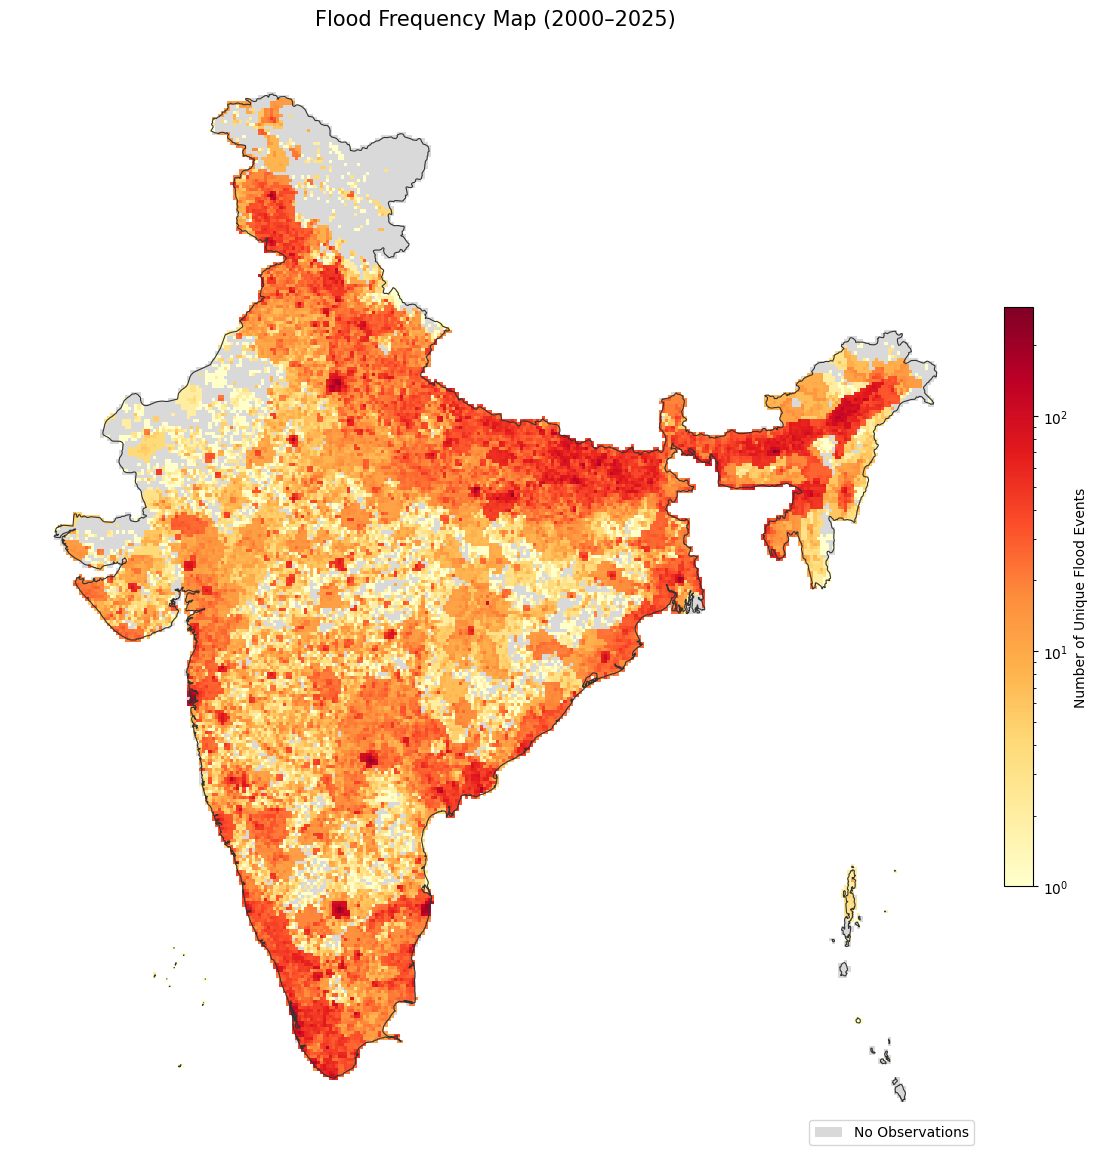

In [36]:
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 12))

# Cells with no observations in neutral grey
grid_country[grid_country['flood_count'] == 0].plot(
    ax=ax, color='#d9d9d9', linewidth=0
)

# Cells with observations coloured by flood count
# (flood counts are heavily right-skewed; log scale reveals spatial variation)
norm = mcolors.LogNorm(vmin=1, vmax=grid_country['flood_count'].max())
cmap = 'YlOrRd'

non_zero = grid_country[grid_country['flood_count'] > 0]
non_zero.plot(
    ax=ax, column='flood_count',
    cmap=cmap, norm=norm, linewidth=0
)

# Add Colorbar (Legend for flood counts)
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Number of Unique Flood Events', fontsize=10)

# Add manual legend for the 'No Data' category
legend_elements = [Patch(facecolor='#d9d9d9', label='No Observations')]
ax.legend(handles=legend_elements, loc='lower right', frameon=True)

# Country boundary
country_proj.plot(ax=ax, facecolor='none', edgecolor='#333333', linewidth=0.8)

ax.set_title('Flood Frequency Map (2000–2025)', fontsize=15, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

Save the results to a GeoPackage.

In [37]:
output_filename = 'flood_frequency_grid.gpkg'
output_filepath = os.path.join(output_folder, output_filename)
grid_country.to_file(output_filepath)